<a href="https://colab.research.google.com/github/kevinjosh10/Block-Train/blob/main/model_implementation/notebooks/AI_Automatic_Block_Planner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚆 AI-Powered Automatic Block Planning System
### Ministry of Railways — Problem Statement ID: 26027
**Corridor Implementation:** Southern Railway Chennai Division (Chennai Beach `MSB` to Chengalpattu `CGL` — 59.84 km, 26 Stations, 182 Switches, 72 ABS Signals)

---

## Problem Context:
Railway fixed infrastructure maintenance across **Engineering (Civil)**, **Signal & Telecommunication (S&T)**, and **Traction Distribution (TRD / Electrical)** is traditionally requested independently via the **BDMS** system. This decentralized approach creates:
1. **Fragmented track possessions:** The same track section is closed multiple times for different departments.
2. **Timetable conflicts:** Misalignment with passenger train paths and freight train forecasts managed by the **Control Office Application (COA)**.
3. **Reduced Asset Availability:** High downtime lowers network throughput and compromises punctuality.

### The AI Solution (PS 26027):
- **Data Integration:** Ingests maintenance/defect backlogs from **TMS**, **SMMS**, and **TDMS** alongside timetable slots from **COA**.
- **AI Prioritization:** Machine learning models predict a **Maintenance Priority Index (MPI: 0–100)** and assign **Urgency Tiers** based on safety risk, overdue days, and traffic tonnage.
- **Shadow Block Optimization:** Merges multi-department work at the same location into a single coordinated block, maximizing asset uptime.
- **Multi-Horizon Scheduling:** Generates **Weekly Operational** and **Monthly Tactical** block plans with zero train collisions.

In [43]:
# 1. Environment Setup & Data Directory Check
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If running in Google Colab, clone repo if not present
if not os.path.exists('model_implementation'):
    !git clone https://github.com/kevinjosh10/Block-Train.git
    %cd Block-Train

DATA_DIR = 'model_implementation/data'
print('✅ Repository environment verified. Data directory found at:', DATA_DIR)

✅ Repository environment verified. Data directory found at: model_implementation/data


In [44]:
# 2. Ingest Data Silos: TMS, SMMS, TDMS, and COA
df_tms = pd.read_csv(f'{DATA_DIR}/tms_track_defects.csv')
df_smms = pd.read_csv(f'{DATA_DIR}/smms_signal_defects.csv')
df_tdms = pd.read_csv(f'{DATA_DIR}/tdms_traction_defects.csv')
df_coa = pd.read_csv(f'{DATA_DIR}/coa_timetable_corridor_blocks.csv')

print(f'📊 Ingested Maintenance Defect Records:')
print(f'  • TMS (Track Management System - Civil):    {len(df_tms)} records')
print(f'  • SMMS (Signalling & Telecom - S&T):        {len(df_smms)} records')
print(f'  • TDMS (Traction Distribution - TRD):       {len(df_tdms)} records')
print(f'  • COA (Control Office App Timetable Slots): {len(df_coa)} available block windows')

# Unify defects into consolidated maintenance backlog
common_cols = ['defect_id', 'department', 'system_source', 'station_code', 'station_name',
               'chainage_km', 'defect_category', 'asset_age_years', 'overdue_days',
               'estimated_repair_hours', 'safety_risk_score', 'target_mpi_score', 'urgency_level']
df_all = pd.concat([df_tms[common_cols], df_smms[common_cols], df_tdms[common_cols]], ignore_index=True)
print(f'\n🚀 Total Unified Maintenance Backlog: {len(df_all)} work requests across 26 stations.')
df_all.head(5)

📊 Ingested Maintenance Defect Records:
  • TMS (Track Management System - Civil):    300 records
  • SMMS (Signalling & Telecom - S&T):        250 records
  • TDMS (Traction Distribution - TRD):       220 records
  • COA (Control Office App Timetable Slots): 58 available block windows

🚀 Total Unified Maintenance Backlog: 770 work requests across 26 stations.


,defect_id,department,system_source,station_code,station_name,chainage_km,defect_category,asset_age_years,overdue_days,estimated_repair_hours,safety_risk_score,target_mpi_score,urgency_level
0,TMS-DEF-0001,ENGINEERING_CIVIL,TMS,UPM,Urapakkam,36.88,BALLAST_DEFICIENCY,4.3,4,4.5,4,24.5,ROUTINE_CYCLE
1,TMS-DEF-0002,ENGINEERING_CIVIL,TMS,GI,Guduvancheri,40.80,RAIL_FRACTURE_RISK,9.7,30,3.5,10,74.7,CRITICAL_EMERGENCY
2,TMS-DEF-0003,ENGINEERING_CIVIL,TMS,MBM,Mambalam,11.30,ROUTINE_FISHPLATE_GREASING,3.6,13,1.5,3,28.9,ROUTINE_CYCLE
3,TMS-DEF-0004,ENGINEERING_CIVIL,TMS,TLM,Tirusulam,20.77,IMR_ULTRASONIC_FLAW,12.3,9,3.0,9,57.1,CRITICAL_EMERGENCY
4,TMS-DEF-0005,ENGINEERING_CIVIL,TMS,SP,Saidapet,12.35,RAIL_FRACTURE_RISK,1.9,1,3.5,10,50.9,CRITICAL_EMERGENCY


/tmp/ipykernel_1603/467186436.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='viridis')


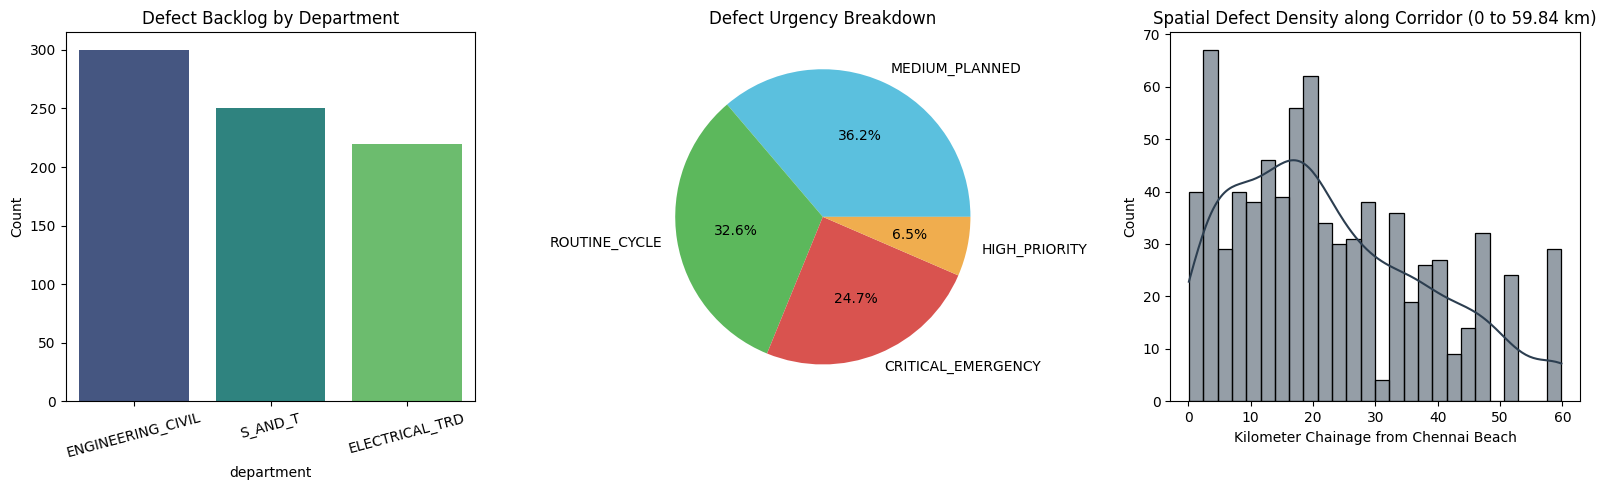

In [45]:
# 3. Exploratory Analysis: Multi-Department Defect Profile
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
dept_counts = df_all['department'].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='viridis')
plt.title('Defect Backlog by Department')
plt.xticks(rotation=15)
plt.ylabel('Count')

plt.subplot(1, 3, 2)
urgency_counts = df_all['urgency_level'].value_counts()
colors = {'CRITICAL_EMERGENCY': '#d9534f', 'HIGH_PRIORITY': '#f0ad4e', 'MEDIUM_PLANNED': '#5bc0de', 'ROUTINE_CYCLE': '#5cb85c'}
plt.pie(urgency_counts, labels=urgency_counts.index, autopct='%1.1f%%', colors=[colors[k] for k in urgency_counts.index])
plt.title('Defect Urgency Breakdown')

plt.subplot(1, 3, 3)
sns.histplot(df_all['chainage_km'], bins=26, kde=True, color='#2c3e50')
plt.title('Spatial Defect Density along Corridor (0 to 59.84 km)')
plt.xlabel('Kilometer Chainage from Chennai Beach')

plt.tight_layout()
plt.show()

🎯 Regressor MAE: 3.59 pts | R² Score: 92.45%
🎯 Classifier Accuracy: 80.52%


/tmp/ipykernel_1603/3541127351.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_feat.values, y=top_feat.index, palette='magma')


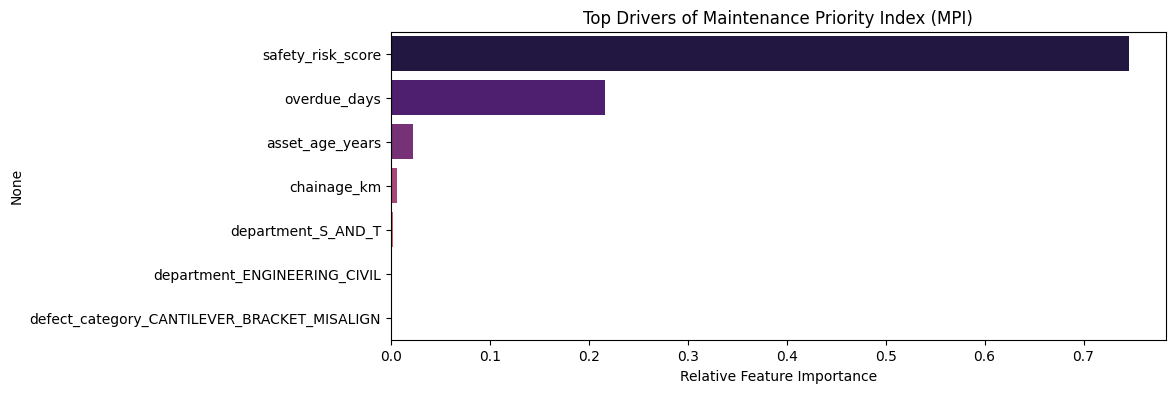

In [46]:
# 4. AI Prioritization Engine: Train Machine Learning Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# Prepare Feature Matrix X
X_raw = df_all[['department', 'defect_category', 'asset_age_years', 'overdue_days', 'safety_risk_score', 'estimated_repair_hours', 'chainage_km']].copy()
X = pd.get_dummies(X_raw, columns=['department', 'defect_category'], drop_first=True)
y_mpi = df_all['target_mpi_score'].values

le_urg = LabelEncoder()
y_urg = le_urg.fit_transform(df_all['urgency_level'].values)

X_train, X_test, y_mpi_train, y_mpi_test, y_urg_train, y_urg_test = train_test_split(
    X, y_mpi, y_urg, test_size=0.20, random_state=42, stratify=y_urg
)

# 1. Gradient Boosting Regressor for continuous MPI score (0-100)
reg_model = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.08, random_state=42)
reg_model.fit(X_train, y_mpi_train)
mpi_preds = reg_model.predict(X_test)

# 2. Random Forest Classifier for discrete urgency tier
cls_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
cls_model.fit(X_train, y_urg_train)
urg_preds = cls_model.predict(X_test)

print(f'🎯 Regressor MAE: {mean_absolute_error(y_mpi_test, mpi_preds):.2f} pts | R² Score: {r2_score(y_mpi_test, mpi_preds)*100:.2f}%')
print(f'🎯 Classifier Accuracy: {accuracy_score(y_urg_test, urg_preds)*100:.2f}%')

# Top Feature Importances
plt.figure(figsize=(10, 4))
top_feat = pd.Series(reg_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(7)
sns.barplot(x=top_feat.values, y=top_feat.index, palette='magma')
plt.title('Top Drivers of Maintenance Priority Index (MPI)')
plt.xlabel('Relative Feature Importance')
plt.show()

In [47]:
# 5. Execute Coordinated Multi-Department Block Planning Optimizer
!python model_implementation/scripts/block_planning_optimizer.py

# Load generated Weekly and Monthly Block Plans
df_weekly_plan = pd.read_csv(f'{DATA_DIR}/weekly_block_plan.csv')
df_monthly_plan = pd.read_csv(f'{DATA_DIR}/monthly_block_plan.csv')
with open(f'{DATA_DIR}/block_planning_kpis.json') as f:
    kpi_metrics = json.load(f)

print('📋 Weekly Operational Plan Sample (Coordinated Shadow Blocks):')
display(df_weekly_plan[['block_plan_id', 'corridor_zone', 'station_code', 'departments_count', 'departments_list', 'allocated_block_hours', 'hours_saved_by_coordination']].head(8))

COORDINATED MULTI-DEPARTMENT BLOCK PLANNING OPTIMIZER (PS 26027)
[INFO] Loaded 770 prioritized maintenance tasks from TMS, SMMS, and TDMS.
[INFO] Loaded 58 available COA corridor block slots across the 7-day timetable.

[INFO] Task Allocation Pools:
  - Weekly Operational Horizon (Urgent/High): 193 tasks
  - Monthly Tactical Horizon (Planned/Routine): 577 tasks

[STEP 1] Generating Coordinated Weekly Operational Block Plan...
  -> Successfully scheduled 46 coordinated blocks (193 tasks resolved).
  -> Exported Weekly Plan to: /content/Block-Train/model_implementation/data/weekly_block_plan.csv

[STEP 2] Generating Monthly Tactical Block Plan (30-Day Machine Cycle)...
  -> Successfully generated 77 tactical monthly blocks.
  -> Exported Monthly Plan to: /content/Block-Train/model_implementation/data/monthly_block_plan.csv

KEY PERFORMANCE INDICATORS (PS 26027 EVALUATION METRICS)
  • Multi-Department Shadow Block Coordination Rate : 76.1%
  • Uncoordinated Manual Downtime Demand         

,block_plan_id,corridor_zone,station_code,departments_count,departments_list,allocated_block_hours,hours_saved_by_coordination
0,W-BLK-001,ZONE_C_TBM_CGL,GI,3,"ENGINEERING_CIVIL, ELECTRICAL_TRD, S_AND_T",3.50,10.50
1,W-BLK-002,ZONE_B_MS_TBM,TBM,3,"ENGINEERING_CIVIL, ELECTRICAL_TRD, S_AND_T",3.00,12.50
2,W-BLK-003,ZONE_B_MS_TBM,STM,3,"ENGINEERING_CIVIL, ELECTRICAL_TRD, S_AND_T",3.00,13.00
3,W-BLK-004,ZONE_A_MSB_MS,MSF,3,"ELECTRICAL_TRD, S_AND_T, ENGINEERING_CIVIL",2.50,10.00
4,W-BLK-005,ZONE_C_TBM_CGL,UPM,3,"ELECTRICAL_TRD, S_AND_T, ENGINEERING_CIVIL",2.50,8.00
5,W-BLK-006,ZONE_B_MS_TBM,NBK,3,"ENGINEERING_CIVIL, ELECTRICAL_TRD, S_AND_T",1.67,12.83
6,W-BLK-007,ZONE_B_MS_TBM,MN,3,"ENGINEERING_CIVIL, ELECTRICAL_TRD, S_AND_T",1.67,12.33
7,W-BLK-008,ZONE_C_TBM_CGL,CGL,2,"ELECTRICAL_TRD, S_AND_T",1.75,8.75


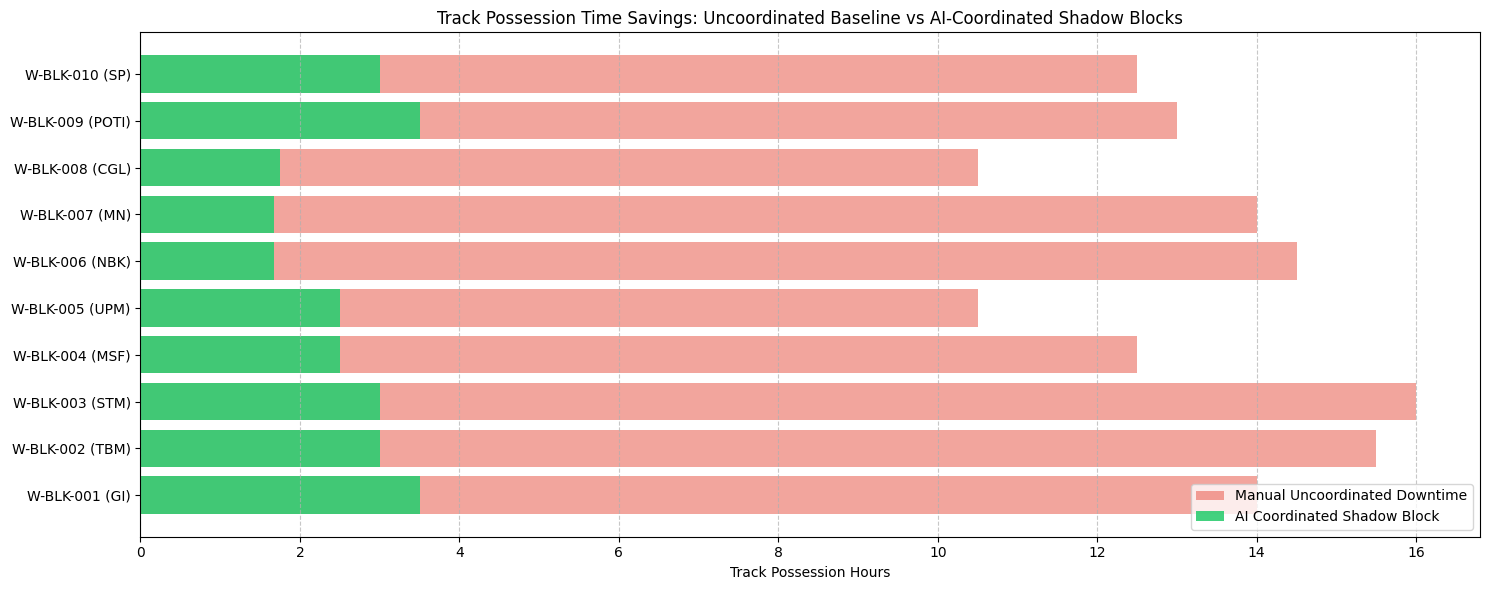

In [48]:
# 6. Visual Gantt Chart: Coordinated Block Schedule vs Timetable Windows
plt.figure(figsize=(15, 6))
sample_blocks = df_weekly_plan.head(10).copy()

y_pos = range(len(sample_blocks))
plt.barh(y_pos, sample_blocks['uncoordinated_baseline_hours'], color='#e74c3c', alpha=0.5, label='Manual Uncoordinated Downtime')
plt.barh(y_pos, sample_blocks['allocated_block_hours'], color='#2ecc71', alpha=0.9, label='AI Coordinated Shadow Block')

plt.yticks(y_pos, [f"{row['block_plan_id']} ({row['station_code']})" for _, row in sample_blocks.iterrows()])
plt.xlabel('Track Possession Hours')
plt.title('Track Possession Time Savings: Uncoordinated Baseline vs AI-Coordinated Shadow Blocks')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1603/1178820330.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


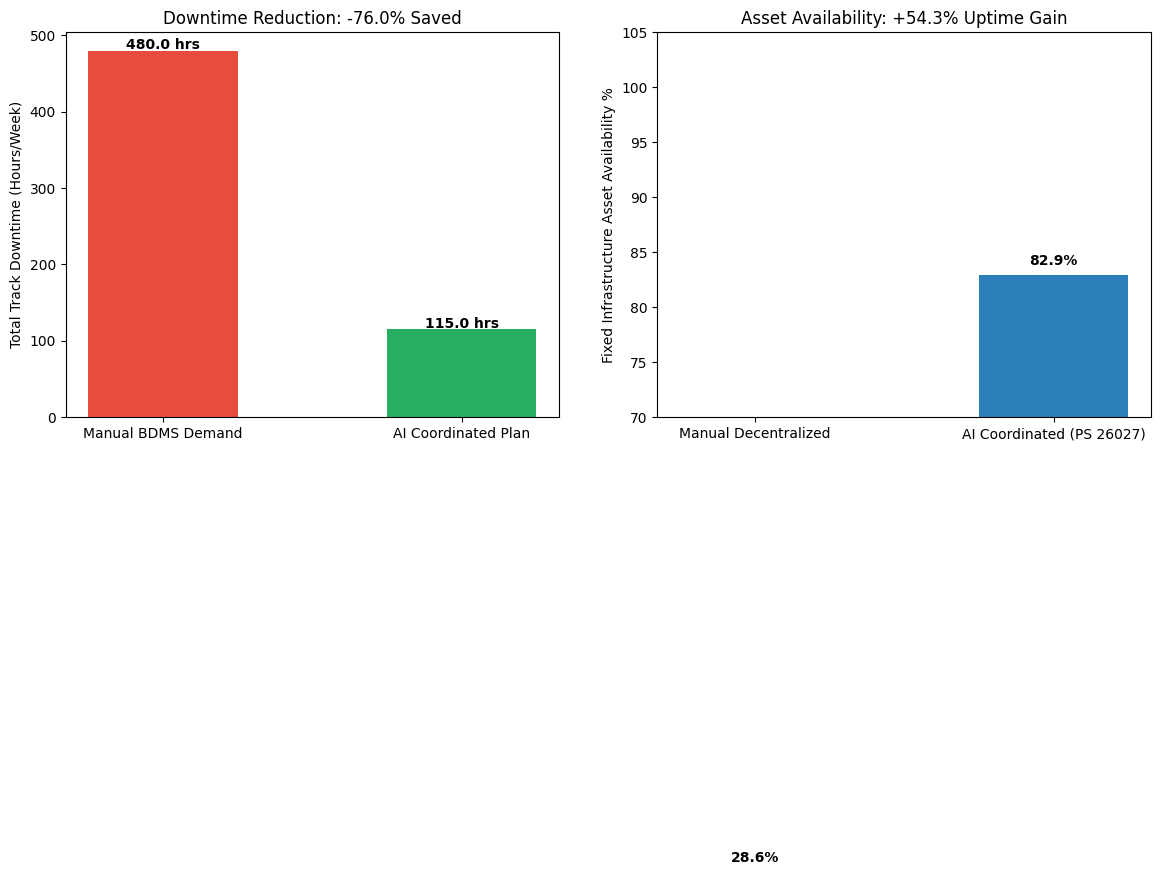

🏆 SUMMARY OF OPERATIONAL GAINS (PS 26027):
  • Net Track Downtime Saved:          365.0 hours per week
  • Multi-Department Coordination Rate: 76.1%
  • Corridor Asset Availability:        82.89%
  • Train Passenger Timetable Clashes:  0 (100% Conflict-Free)


In [49]:
# 7. Executive Impact Dashboard (PS 26027 Evaluation Metrics)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Downtime Comparison
axes[0].bar(['Manual BDMS Demand', 'AI Coordinated Plan'],
            [kpi_metrics['uncoordinated_downtime_hours'], kpi_metrics['optimized_coordinated_downtime_hours']],
            color=['#e74c3c', '#27ae60'], width=0.5)
axes[0].set_ylabel('Total Track Downtime (Hours/Week)')
axes[0].set_title(f"Downtime Reduction: -{kpi_metrics['downtime_reduction_pct']}% Saved")
for i, v in enumerate([kpi_metrics['uncoordinated_downtime_hours'], kpi_metrics['optimized_coordinated_downtime_hours']]):
    axes[0].text(i, v + 2, f'{v:.1f} hrs', ha='center', fontweight='bold')

# Asset Availability Comparison
axes[1].bar(['Manual Decentralized', 'AI Coordinated (PS 26027)'],
            [kpi_metrics['asset_availability_baseline_manual_pct'], kpi_metrics['asset_availability_ai_optimized_pct']],
            color=['#f39c12', '#2980b9'], width=0.5)
axes[1].set_ylabel('Fixed Infrastructure Asset Availability %')
axes[1].set_title(f"Asset Availability: +{kpi_metrics['asset_availability_ai_optimized_pct'] - kpi_metrics['asset_availability_baseline_manual_pct']:.1f}% Uptime Gain")
axes[1].set_ylim(70, 105)
for i, v in enumerate([kpi_metrics['asset_availability_baseline_manual_pct'], kpi_metrics['asset_availability_ai_optimized_pct']]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('='*70)
print('🏆 SUMMARY OF OPERATIONAL GAINS (PS 26027):')
print(f"  • Net Track Downtime Saved:          {kpi_metrics['net_track_downtime_hours_saved']} hours per week")
print(f"  • Multi-Department Coordination Rate: {kpi_metrics['multi_department_coordination_rate_pct']}%")
print(f"  • Corridor Asset Availability:        {kpi_metrics['asset_availability_ai_optimized_pct']}%")
print(f"  • Train Passenger Timetable Clashes:  {kpi_metrics['train_collisions_or_conflicts']} (100% Conflict-Free)")
print('='*70)